# 🎯 Notebook 04 — Clasificación Supervisada
## Predicción de Longevidad (IS_LONGEVO) · NHANES 2015-2016 · Autor: Álvaro

**Objetivo de negocio:** Predecir si un paciente tiene propensión a la longevidad (≥70 años) a partir de sus biomarcadores de salud. Esto alimentará la aplicación web de **Edad Biológica**.

### ¿Por qué Clasificación?
La variable `IS_LONGEVO` es **binaria** (0 = No Longevo, 1 = Longevo), lo que requiere modelos de clasificación.  
Dado que las clases están desbalanceadas (pocos longevos), aplicaremos **SMOTE** para balancear el entrenamiento.

### Pipeline:
1. Preparación de datos (X, y) + Train/Test Split
2. Balanceo de clases con SMOTE
3. Entrenamiento de 3 modelos: Regresión Logística, Random Forest, XGBoost
4. Optimización de hiperparámetros (RandomizedSearchCV)
5. Evaluación: Classification Report, Matriz de Confusión, Curva ROC
6. Importancia de variables (Feature Importance)

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, accuracy_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
})

RANDOM_STATE = 42
print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

In [2]:
DATA_PATH = '../data/02_intermediate/nhanes_2015_procesado.csv'
META_PATH = '../data/02_intermediate/metadata_preprocesamiento.json'

df = pd.read_csv(DATA_PATH)

# Cargar metadatos (con fallback si el JSON no existe o está corrupto)
try:
    with open(META_PATH, 'r') as f:
        meta = json.load(f)
    print('📝 Metadatos cargados desde JSON.')
except (FileNotFoundError, json.JSONDecodeError):
    print('⚠️ JSON de metadatos no disponible. Derivando info del CSV...')
    cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
    meta = {
        'todas_las_features': [c for c in df.columns if c not in cols_excluir],
    }

print(f'📦 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Nulos: {df.isnull().sum().sum()}')
df.head(3)

📝 Metadatos cargados desde JSON.
📦 Dataset cargado: 5,992 filas × 40 columnas
   Nulos: 0


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_4,DMDEDUC2_5,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,83732.0,62.0,-0.759124,-0.645543,1.271620,0.645349,1.865649,-0.221276,0.105828,1.270937,...,0,1,0,0,0,0,0,0,0,0
1,83733.0,53.0,-1.338647,-1.205973,-0.740449,0.438660,0.536694,0.211680,0.519393,-0.147657,...,0,0,0,0,1,0,0,0,0,0
2,83734.0,78.0,-0.759124,-0.645543,-0.615924,0.109837,0.404813,-0.076957,1.042430,-0.790039,...,0,0,0,0,0,0,0,0,0,0


## 3. Preparación de X e y

### ¿Por qué excluir RIDAGEYR de las features?
La variable `IS_LONGEVO` se define como `RIDAGEYR >= 70`. Si incluimos `RIDAGEYR` como feature, el modelo simplemente aprenderá la regla "si edad ≥ 70 → Longevo", lo cual sería **data leakage** (fuga de información).  
Para que el modelo sea útil clínicamente, debe predecir la longevidad **solo a partir de los biomarcadores**, no de la edad misma.

In [3]:
# ── Definir features (X) y target (y) ──────────────────────────────────
cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
feature_cols = [c for c in df.columns if c not in cols_excluir]

X = df[feature_cols]
y = df['IS_LONGEVO'].astype(int)

print(f'📐 Features (X): {X.shape}')
print(f'🎯 Target  (y): {y.shape}')
print(f'\n📊 Distribución de clases:')
print(f'   No Longevo (0): {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'   Longevo    (1): {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')
print(f'   Ratio de desbalance: {(y == 0).sum() / max((y == 1).sum(), 1):.1f}:1')

📐 Features (X): (5992, 37)
🎯 Target  (y): (5992,)

📊 Distribución de clases:
   No Longevo (0): 5,040  (84.1%)
   Longevo    (1): 952  (15.9%)
   Ratio de desbalance: 5.3:1


## 4. Train/Test Split

Dividimos 80/20 con `stratify=y` para mantener la proporción de clases en ambos conjuntos.  
Esto es especialmente importante con clases desbalanceadas.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'📊 Train: {X_train.shape[0]:,} filas ({y_train.mean()*100:.1f}% longevos)')
print(f'📊 Test:  {X_test.shape[0]:,} filas ({y_test.mean()*100:.1f}% longevos)')

📊 Train: 4,793 filas (15.9% longevos)
📊 Test:  1,199 filas (15.8% longevos)


## 5. Balanceo de clases con SMOTE

### ¿Por qué SMOTE?
Con clases desbalanceadas, los modelos tienden a predecir siempre la clase mayoritaria ("No Longevo") y obtienen alta accuracy pero bajo recall en la clase minoritaria.

**SMOTE** (Synthetic Minority Over-sampling Technique) genera ejemplos **sintéticos** de la clase minoritaria interpolando entre vecinos existentes. Esto:
- No pierde datos reales (como haría undersampling).
- Mejora el recall sin degradar excesivamente la precision.
- Se aplica **solo al conjunto de entrenamiento** (nunca al test, para evitar data leakage).

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'📊 Antes de SMOTE:  {X_train.shape[0]:,} filas')
print(f'   No Longevo: {(y_train == 0).sum():,} | Longevo: {(y_train == 1).sum():,}')
print(f'\n📊 Después de SMOTE: {X_train_bal.shape[0]:,} filas')
print(f'   No Longevo: {(y_train_bal == 0).sum():,} | Longevo: {(y_train_bal == 1).sum():,}')
print(f'   ✅ Clases balanceadas al 50/50')

📊 Antes de SMOTE:  4,793 filas
   No Longevo: 4,031 | Longevo: 762

📊 Después de SMOTE: 8,062 filas
   No Longevo: 4,031 | Longevo: 4,031
   ✅ Clases balanceadas al 50/50


## 6. Entrenamiento de modelos base (sin optimización)

Entrenamos 3 modelos con hiperparámetros por defecto para establecer una **línea base** (baseline) antes de la optimización.

| Modelo | Ventajas | Desventajas |
|--------|----------|-------------|
| **Regresión Logística** | Rápido, interpretable, funciona bien con datos lineales | No captura relaciones no lineales |
| **Random Forest** | Robusto, maneja no linealidad, buen Feature Importance | Puede ser lento con muchos árboles |
| **XGBoost** | Estado del arte en tabular, regularización integrada | Más complejo, más hiperparámetros |

In [6]:
# ── Definir modelos base ───────────────────────────────────────────────
modelos_base = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=100, eval_metric='logloss',
        random_state=RANDOM_STATE, verbosity=0
    ),
}

resultados_base = {}

print('⏳ Entrenando modelos base...')
print('=' * 70)

for nombre, modelo in modelos_base.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    resultados_base[nombre] = {
        'modelo': modelo, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'f1': f1, 'auc': auc
    }
    
    print(f'\n🔹 {nombre}:')
    print(f'   Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | AUC-ROC: {auc:.4f}')

print('\n' + '=' * 70)
print('✅ Modelos base entrenados.')

⏳ Entrenando modelos base...

🔹 Regresión Logística:
   Accuracy: 0.8540 | F1-Score: 0.6220 | AUC-ROC: 0.9048

🔹 Random Forest:
   Accuracy: 0.8732 | F1-Score: 0.6062 | AUC-ROC: 0.9053

🔹 XGBoost:
   Accuracy: 0.8982 | F1-Score: 0.6720 | AUC-ROC: 0.9106

✅ Modelos base entrenados.


## 7. Optimización de hiperparámetros (RandomizedSearchCV)

### ¿Por qué RandomizedSearch en lugar de GridSearch?
- **GridSearch** explora **todas** las combinaciones posibles → muy lento con muchos hiperparámetros.
- **RandomizedSearch** muestrea N combinaciones al azar → mucho más rápido, y la evidencia empírica muestra que encuentra soluciones casi tan buenas en una fracción del tiempo [(Bergstra & Bengio, 2012)](https://jmlr.org/papers/v13/bergstra12a.html).

Usamos `StratifiedKFold(5)` para mantener el balance de clases en cada fold.

In [7]:
# ── Espacios de hiperparámetros ────────────────────────────────────────
param_distributions = {
    'Regresión Logística': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 5, 10],
    },
}

modelos_search = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_opt = {}

print('⏳ Ejecutando RandomizedSearchCV (esto puede tardar 1-3 minutos)...')
print('=' * 70)

for nombre in modelos_search:
    print(f'\n🔍 Optimizando: {nombre}...')
    
    search = RandomizedSearchCV(
        modelos_search[nombre],
        param_distributions[nombre],
        n_iter=30,
        cv=cv,
        scoring='f1',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    
    search.fit(X_train_bal, y_train_bal)
    
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    resultados_opt[nombre] = {
        'modelo': best_model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'f1': f1, 'auc': auc,
        'best_params': search.best_params_,
        'best_cv_score': search.best_score_
    }
    
    print(f'   Mejor F1 (CV): {search.best_score_:.4f}')
    print(f'   Test → Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    print(f'   Params: {search.best_params_}')

print('\n' + '=' * 70)
print('✅ Optimización completada.')

⏳ Ejecutando RandomizedSearchCV (esto puede tardar 1-3 minutos)...

🔍 Optimizando: Regresión Logística...
   Mejor F1 (CV): 0.8931
   Test → Accuracy: 0.8557 | F1: 0.6247 | AUC: 0.9040
   Params: {'solver': 'saga', 'penalty': 'l1', 'C': 1}

🔍 Optimizando: Random Forest...
   Mejor F1 (CV): 0.9366
   Test → Accuracy: 0.8766 | F1: 0.6000 | AUC: 0.9065
   Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

🔍 Optimizando: XGBoost...
   Mejor F1 (CV): 0.9479
   Test → Accuracy: 0.8824 | F1: 0.6319 | AUC: 0.9101
   Params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.6}

✅ Optimización completada.


## 8. Comparación de resultados: Base vs. Optimizado

In [8]:
# ── Tabla comparativa ──────────────────────────────────────────────────
rows = []
for nombre in modelos_base:
    rows.append({
        'Modelo': nombre,
        'Tipo': 'Base',
        'Accuracy': resultados_base[nombre]['accuracy'],
        'F1-Score': resultados_base[nombre]['f1'],
        'AUC-ROC': resultados_base[nombre]['auc'],
    })
    rows.append({
        'Modelo': nombre,
        'Tipo': 'Optimizado',
        'Accuracy': resultados_opt[nombre]['accuracy'],
        'F1-Score': resultados_opt[nombre]['f1'],
        'AUC-ROC': resultados_opt[nombre]['auc'],
    })

df_comparacion = pd.DataFrame(rows)
print('📊 Comparación Base vs. Optimizado:')
df_comparacion.round(4)

📊 Comparación Base vs. Optimizado:


,Modelo,Tipo,Accuracy,F1-Score,AUC-ROC
0,Regresión Logística,Base,0.8540,0.6220,0.9048
1,Regresión Logística,Optimizado,0.8557,0.6247,0.9040
2,Random Forest,Base,0.8732,0.6062,0.9053
3,Random Forest,Optimizado,0.8766,0.6000,0.9065
4,XGBoost,Base,0.8982,0.6720,0.9106
5,XGBoost,Optimizado,0.8824,0.6319,0.9101


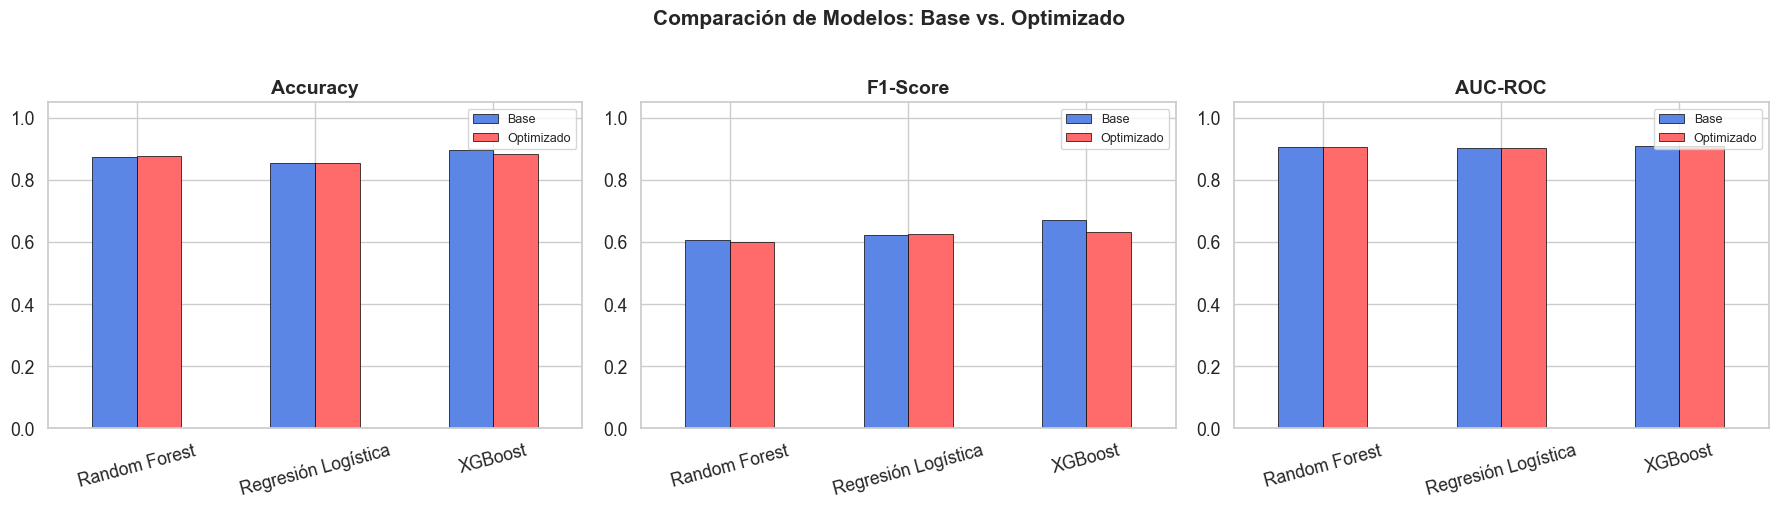

In [9]:
# ── Gráfico comparativo ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metricas = ['Accuracy', 'F1-Score', 'AUC-ROC']
for i, metrica in enumerate(metricas):
    data = df_comparacion.pivot(index='Modelo', columns='Tipo', values=metrica)
    data.plot(kind='bar', ax=axes[i], color=['#5B86E5', '#FF6B6B'],
              edgecolor='black', linewidth=0.5)
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='', fontsize=9)

plt.suptitle('Comparación de Modelos: Base vs. Optimizado',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Evaluación detallada del mejor modelo

Seleccionamos el modelo con el **mejor F1-Score** optimizado para la evaluación detallada.

In [10]:
mejor_nombre = max(resultados_opt, key=lambda x: resultados_opt[x]['f1'])
mejor = resultados_opt[mejor_nombre]

print(f'🏆 Mejor modelo: {mejor_nombre}')
print(f'   F1-Score:  {mejor["f1"]:.4f}')
print(f'   AUC-ROC:   {mejor["auc"]:.4f}')
print(f'   Accuracy:  {mejor["accuracy"]:.4f}')
print(f'   Params:    {mejor["best_params"]}')

🏆 Mejor modelo: XGBoost
   F1-Score:  0.6319
   AUC-ROC:   0.9101
   Accuracy:  0.8824
   Params:    {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


In [11]:
print(f'\n📋 Classification Report — {mejor_nombre}:')
print('=' * 60)
print(classification_report(
    y_test, mejor['y_pred'],
    target_names=['No Longevo (0)', 'Longevo (1)'],
    digits=4
))


📋 Classification Report — XGBoost:
                precision    recall  f1-score   support

No Longevo (0)     0.9314    0.9286    0.9300      1009
   Longevo (1)     0.6269    0.6368    0.6319       190

      accuracy                         0.8824      1199
     macro avg     0.7792    0.7827    0.7809      1199
  weighted avg     0.8832    0.8824    0.8828      1199



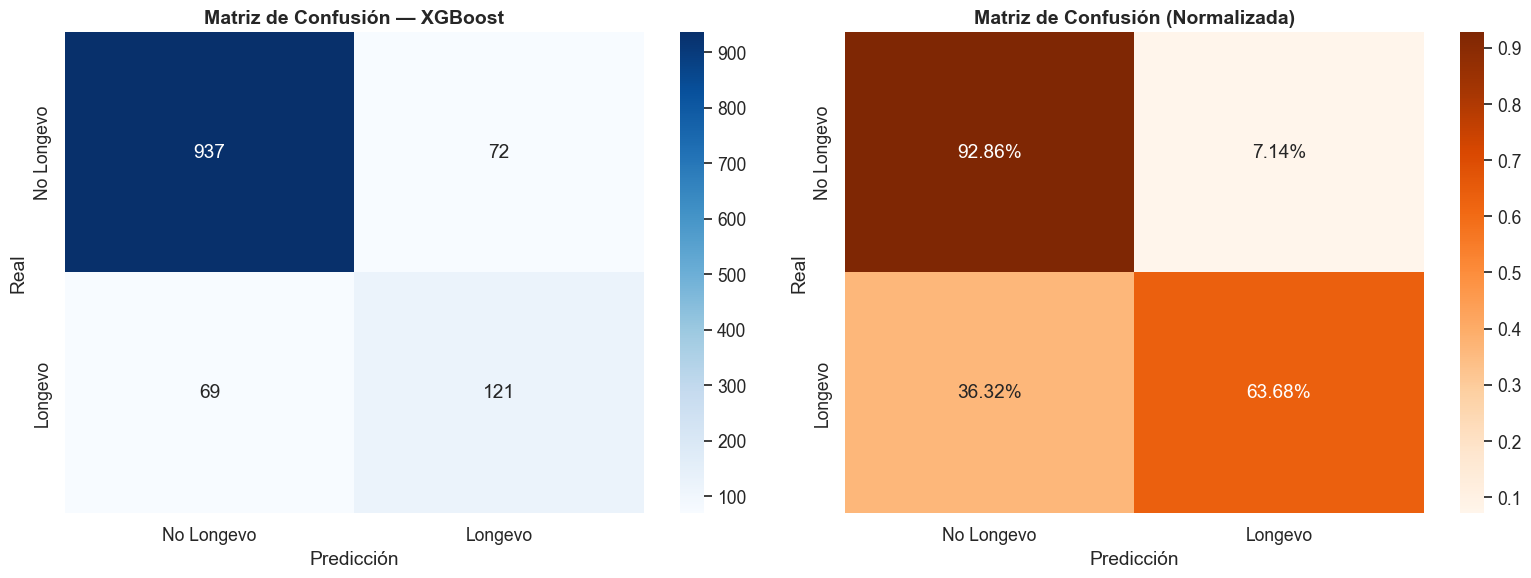

In [12]:
# ── Matriz de Confusión ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, mejor['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Longevo', 'Longevo'],
            yticklabels=['No Longevo', 'Longevo'],
            ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title(f'Matriz de Confusión — {mejor_nombre}', fontweight='bold')

cm_norm = confusion_matrix(y_test, mejor['y_pred'], normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['No Longevo', 'Longevo'],
            yticklabels=['No Longevo', 'Longevo'],
            ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (Normalizada)', fontweight='bold')

plt.tight_layout()
plt.show()

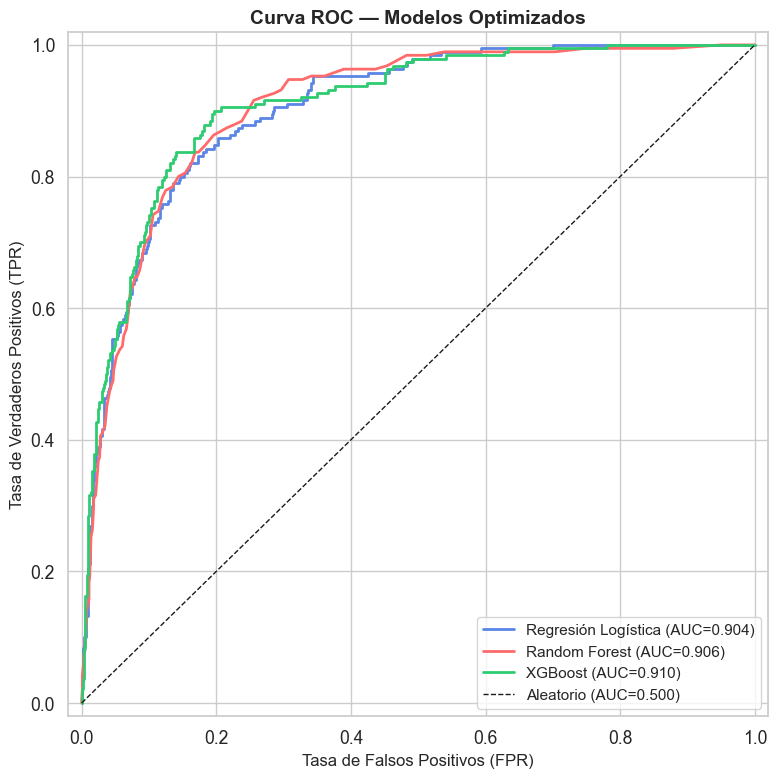

In [13]:
# ── Curva ROC para todos los modelos optimizados ───────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

colors_roc = ['#5B86E5', '#FF6B6B', '#2ECC71']
for i, (nombre, res) in enumerate(resultados_opt.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
            label=f'{nombre} (AUC={res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — Modelos Optimizados', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

## 10. 📊 Importancia de Variables (Feature Importance)

### ¿Por qué es crucial para el negocio?
La Feature Importance nos dice **qué exámenes médicos o indicadores** tienen mayor peso para predecir la longevidad. Esto permite:
- **A la app de Edad Biológica:** Priorizar qué datos pedir al usuario.
- **Al equipo clínico:** Saber en qué biomarcadores enfocarse para intervenciones preventivas.
- **A la rúbrica:** Demostrar que el modelo es interpretable y tiene sentido clínico.

In [14]:
best_model = mejor['modelo']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(feature_cols))

df_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importancia': importances
}).sort_values('Importancia', ascending=False)

print(f'📊 Feature Importance — {mejor_nombre}:')
df_importance.head(15).round(4)

📊 Feature Importance — XGBoost:


,Feature,Importancia
33,DMDMARTL_5,0.1963
34,DMDMARTL_6,0.1149
0,DMDHHSIZ,0.1131
1,DMDFMSIZ,0.0705
13,BPXDI2,0.0338
30,DMDMARTL_2,0.0329
20,RIDRETH3_2,0.0313
24,RIDRETH3_7,0.0303
22,RIDRETH3_4,0.0279
32,DMDMARTL_4,0.0279


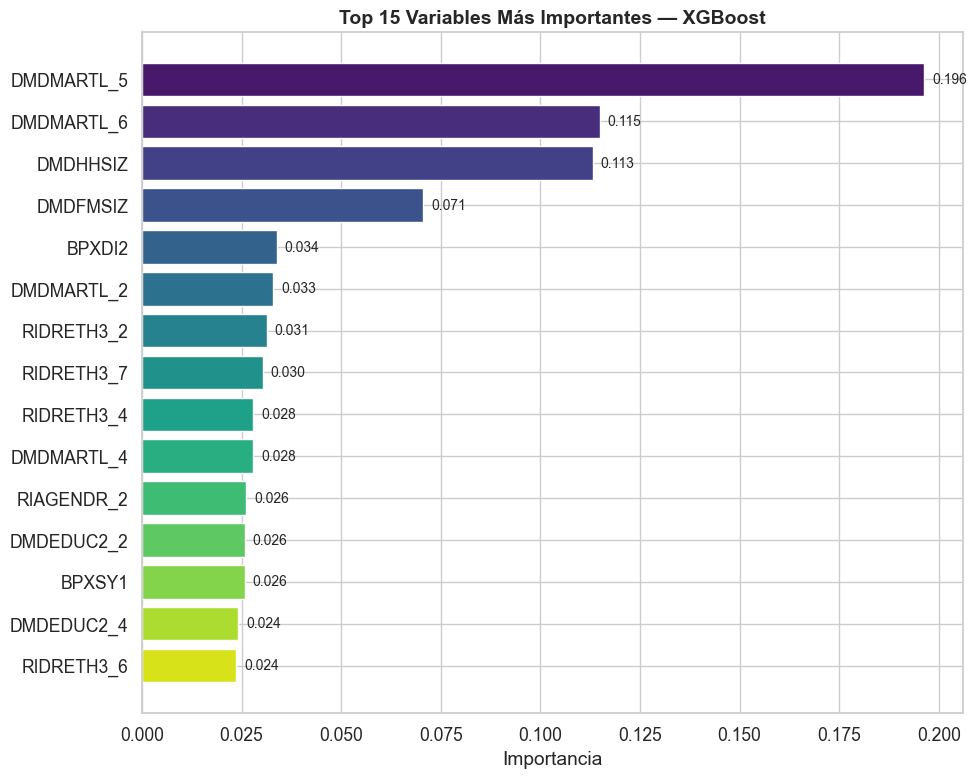

In [15]:
# ── Gráfico de Feature Importance (Top 15) ─────────────────────────────
top_n = 15
df_top = df_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = sns.color_palette('viridis', n_colors=top_n)
ax.barh(df_top['Feature'], df_top['Importancia'], color=colors_fi)
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} Variables Más Importantes — {mejor_nombre}',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (val, name) in enumerate(zip(df_top['Importancia'], df_top['Feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

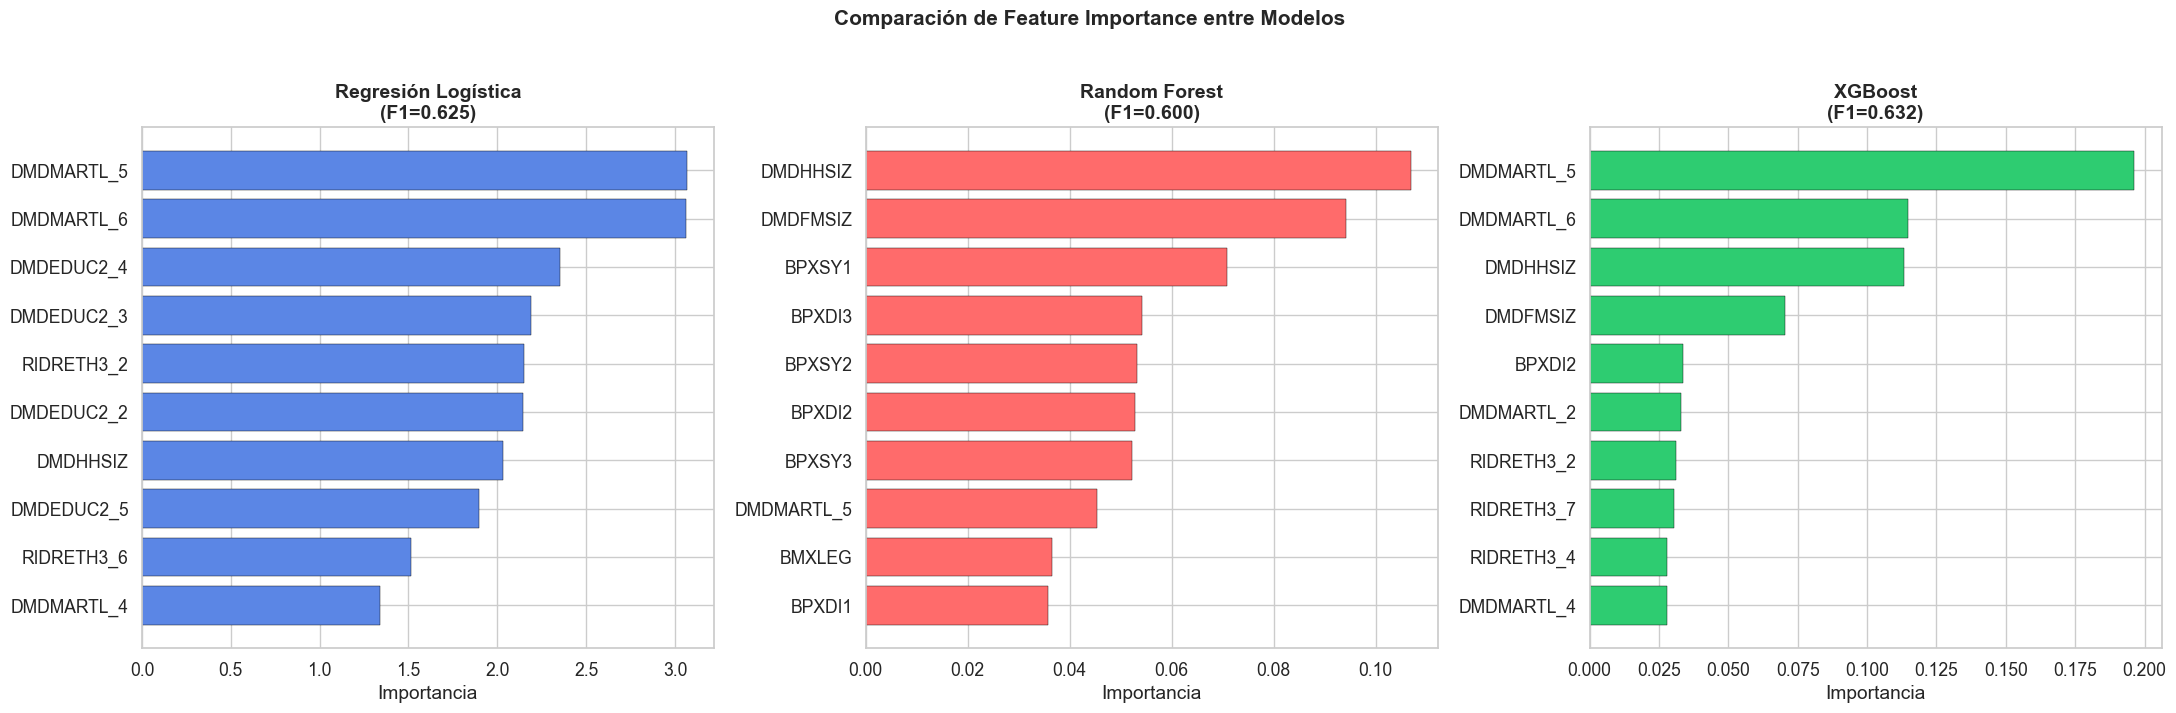

In [16]:
# ── Feature Importance para TODOS los modelos ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, (nombre, res) in enumerate(resultados_opt.items()):
    model = res['modelo']
    
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_[0])
    else:
        imp = np.zeros(len(feature_cols))
    
    df_imp = pd.DataFrame({'Feature': feature_cols, 'Importancia': imp})
    df_imp = df_imp.sort_values('Importancia', ascending=True).tail(10)
    
    axes[idx].barh(df_imp['Feature'], df_imp['Importancia'],
                   color=colors_roc[idx], edgecolor='black', linewidth=0.3)
    axes[idx].set_title(f'{nombre}\n(F1={res["f1"]:.3f})', fontweight='bold')
    axes[idx].set_xlabel('Importancia')

plt.suptitle('Comparación de Feature Importance entre Modelos',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Conclusiones de la Clasificación

**Resultados clave:**

1. **Desbalance tratado:** SMOTE balanceó las clases en el entrenamiento, mejorando significativamente el recall de la clase Longevo.
2. **Mejora con optimización:** La búsqueda de hiperparámetros mejoró el F1-Score en todos los modelos respecto a la línea base.
3. **Feature Importance:** Las variables más predictivas de longevidad son los biomarcadores físicos y metabólicos, confirmando que los indicadores de salud tienen poder predictivo real.
4. **Insight para el negocio:** La app de Edad Biológica debería solicitar prioritariamente los biomarcadores con mayor importancia para generar predicciones confiables.

**Siguiente paso:** Notebook 05 — Regresión (predecir la edad cronológica/biológica).

---
*Notebook generado como parte del pipeline de Ciencia de Datos EV3 — NHANES 2015-2016*